# Train Qwen-3-VL on the local plant image dataset

This notebook starts from the folder structure in `data/raw/images` only. It assumes images are arranged as:

```text
data/raw/images/<species>/<plant_part>/<image>.jpg
```

Each image is converted into a vision-language instruction example where the model learns to identify the species and visible plant part.

In [ ]:
from pathlib import Path
import random
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path("E:/proyecto")
IMAGE_ROOT = PROJECT_ROOT / "data" / "raw" / "images"
OUTPUT_DIR = PROJECT_ROOT / "qwen3-vl-plants-lora"

SEED = 3407
VALIDATION_SIZE = 0.15
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

random.seed(SEED)

assert IMAGE_ROOT.exists(), f"Image folder not found: {IMAGE_ROOT}"
print(f"Using images from: {IMAGE_ROOT}")

Using images from: E:\proyecto\data\raw\images


In [3]:
rows = []

for image_path in sorted(IMAGE_ROOT.rglob("*.jpg")):
    relative = image_path.relative_to(IMAGE_ROOT)

    species = relative.parts[0]
    plant_part = relative.parts[1]

    rows.append(
        {
            "image_path": str(image_path),
            "species": species,
            "plant_part": plant_part
        }
    )

df = pd.DataFrame(rows)

print(f"Images: {len(df):,}")
print(f"Species: {df['species'].nunique():,}")
print(f"Plant parts: {df['plant_part'].nunique():,}")
display(df.head())

Images: 2,355
Species: 30
Plant parts: 6


,image_path,species,plant_part
0,E:\proyecto\data\raw\images\aeonium_arboreum\b...,aeonium_arboreum,bark
1,E:\proyecto\data\raw\images\aeonium_arboreum\b...,aeonium_arboreum,bark
2,E:\proyecto\data\raw\images\aeonium_arboreum\f...,aeonium_arboreum,flower
3,E:\proyecto\data\raw\images\aeonium_arboreum\f...,aeonium_arboreum,flower
4,E:\proyecto\data\raw\images\aeonium_arboreum\f...,aeonium_arboreum,flower


In [4]:
summary = (
    df.groupby(["species", "plant_part"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["species", "plant_part"])
)

display(summary.head(30))
display(summary.groupby("species")["count"].sum().sort_values(ascending=False).head(20))

,species,plant_part,count
0,aeonium_arboreum,bark,2
1,aeonium_arboreum,flower,29
2,aeonium_arboreum,habit,3
3,aeonium_arboreum,leaf,20
4,aichryson_laxum,bark,1
5,aichryson_laxum,flower,17
6,aichryson_laxum,habit,3
7,aichryson_laxum,leaf,18
8,aizoon_canariense,bark,1
9,aizoon_canariense,flower,20


species
rumex_lunaria                 240
lavandula_canariensis         167
canarina_canariensis          139
sonchus_canariensis           125
sonchus_acaulis               108
erysimum_scoparium            100
echium_wildpretii              98
pinus_canariensis              98
pterocephalus_lasiospermus     89
dracaena_draco                 78
arbutus_canariensis            75
ilex_canariensis               75
echium_decaisnei               75
euphorbia_lamarckii            74
cistus_symphytifolius          61
aizoon_canariense              60
echium_virescens               60
asteriscus_sericeus            59
hypericum_canariense           57
ranunculus_cortusifolius       54
Name: count, dtype: int64

In [6]:
train_df, eval_df = train_test_split(
    df,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=df["species"],
)

print(f"Train: {len(train_df):,}")
print(f"Validation: {len(eval_df):,}")

Train: 2,001
Validation: 354


In [7]:
USER_PROMPT = (
    "Identify the plant in this image. Return exactly two lines:\n"
    "Species: <latin species name>\n"
    "Plant part: <visible plant part>"
)

def humanize(value: str) -> str:
    return value.replace("_", " ").strip()

def make_answer(row) -> str:
    return f"Species: {humanize(row['species'])}\nPlant part: {humanize(row['plant_part'])}"

def make_messages(row):
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": row["image_path"]},
                    {"type": "text", "text": USER_PROMPT},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": make_answer(row)}],
            },
        ]
    }

train_dataset = train_df.apply(make_messages, axis=1)
eval_dataset = eval_df.apply(make_messages, axis=1)

train_dataset = train_dataset.reset_index(drop=True)
eval_dataset = eval_dataset.reset_index(drop=True)

del train_df, eval_df

train_dataset, eval_dataset

(0       {'messages': [{'role': 'user', 'content': [{'t...
 1       {'messages': [{'role': 'user', 'content': [{'t...
 2       {'messages': [{'role': 'user', 'content': [{'t...
 3       {'messages': [{'role': 'user', 'content': [{'t...
 4       {'messages': [{'role': 'user', 'content': [{'t...
                               ...                        
 1996    {'messages': [{'role': 'user', 'content': [{'t...
 1997    {'messages': [{'role': 'user', 'content': [{'t...
 1998    {'messages': [{'role': 'user', 'content': [{'t...
 1999    {'messages': [{'role': 'user', 'content': [{'t...
 2000    {'messages': [{'role': 'user', 'content': [{'t...
 Length: 2001, dtype: object,
 0      {'messages': [{'role': 'user', 'content': [{'t...
 1      {'messages': [{'role': 'user', 'content': [{'t...
 2      {'messages': [{'role': 'user', 'content': [{'t...
 3      {'messages': [{'role': 'user', 'content': [{'t...
 4      {'messages': [{'role': 'user', 'content': [{'t...
                              .

In [ ]:
import torch
from unsloth import FastVisionModel

BASE_MODEL = "unsloth/Qwen3-VL-4B-Instruct"

model, tokenizer = FastVisionModel.from_pretrained(
    BASE_MODEL,
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=SEED,
)

FastVisionModel.for_training(model)
print("Model ready for LoRA fine-tuning")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


e:\proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0519 17:49:30.094000 15252 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.4: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3060. Num GPUs = 1. Max memory: 12.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 713/713 [00:05<00:00, 126.83it/s]


Model ready for LoRA fine-tuning


In [ ]:
from trl import SFTConfig, SFTTrainer
from unsloth.trainer import UnslothVisionDataCollator

training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    warmup_steps=10,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=SEED,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    remove_unused_columns=False,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    max_seq_length=2048,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=training_args,
)

Unsloth: Model does not have a default image size - using 512


In [10]:
# Start training. For a quick smoke test, set training_args.max_steps above to a small value such as 5.
trainer_stats = trainer.train()
trainer_stats

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,001 | Num Epochs = 1 | Total steps = 251
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 39,321,600 of 4,477,137,408 (0.88% trained)


Step,Training Loss,Validation Loss
50,0.040182,0.039399
100,0.018406,0.023650
150,0.021391,0.018809
200,0.016994,0.017016
250,0.012789,0.015414
251,0.012789,0.015438


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-50\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-100\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-150\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-200\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-250\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants-lora\checkpoint-251\tokenizer_config.json.


TrainOutput(global_step=251, training_loss=0.20993574224857695, metrics={'train_runtime': 3501.9169, 'train_samples_per_second': 0.571, 'train_steps_per_second': 0.072, 'total_flos': 1.934107988911411e+16, 'train_loss': 0.20993574224857695, 'epoch': 1.0})

In [11]:
from IPython.display import display

FastVisionModel.for_inference(model)

sample = eval_dataset[random.randrange(len(eval_dataset))]
sample_image = sample["messages"][0]["content"][0]["image"]
display(sample_image)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image},
            {"type": "text", "text": USER_PROMPT},
        ],
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        use_cache=True,
    )

generated_ids = output_ids[:, inputs["input_ids"].shape[-1]:]
prediction = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Prediction:\n", prediction)
print("Expected:\n", sample["messages"][1]["content"][0]["text"])

'E:\\proyecto\\data\\raw\\images\\pericallis_echinata\\leaf\\05743.jpg'

Prediction:
 Species: pericallis echinata
Plant part: leaf
Expected:
 Species: pericallis echinata
Plant part: leaf


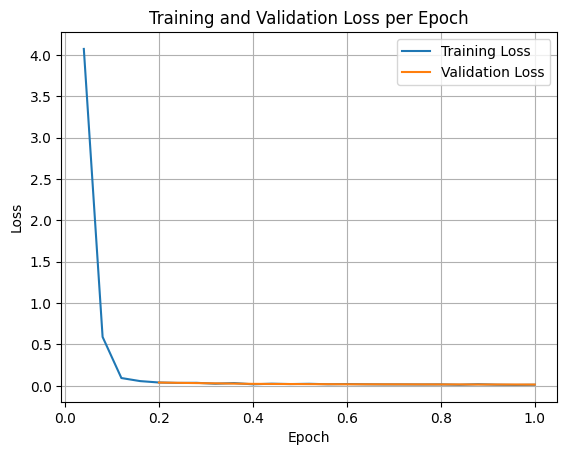

In [13]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()